In [1]:
import copy
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from collections import defaultdict
from torch.utils.data import DataLoader, Subset

import src.data_cleaning_and_preprocessing._model_ready_dataset as model_ready_dataset
from src.dataset.tiny_imagenet_dataset import TinyImageNetLoader
from archive.py_file.pc_supervised_rao_1 import HierarchicalPCCNN

In [2]:
SEED = 42
BATCH_SIZE = 16

IMAGE_SIZE = 64

NUM_CLASSES = 10

TRAIN_IMAGES_PER_CLASS = 50
VAL_IMAGES_PER_CLASS = 15
TEST_IMAGES_PER_CLASS = 10

INFERENCE_STEPS = 100
PC_EPOCHS = 10

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available() and hasattr(torch.mps, "manual_seed"):
    torch.mps.manual_seed(SEED)

Device: mps


In [4]:
cleaned_tiny_imagenet = model_ready_dataset.ModelReadyDatasetLoader(TinyImageNetLoader(seed=SEED),
                                                                    image_size=IMAGE_SIZE).load()

train_dataset = cleaned_tiny_imagenet[0]
test_dataset = cleaned_tiny_imagenet[1]

print("Full training dataset:", len(train_dataset))
print("Full test dataset:", len(test_dataset))

Full training dataset: 99953
Full test dataset: 9993


In [5]:
selected_classes = list(range(NUM_CLASSES))

print("Selected classes:", selected_classes)
print("Number of selected classes:", len(selected_classes))

Selected classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of selected classes: 10


In [6]:
class_indices = defaultdict(list)

for i in range(len(train_dataset)):
    _, label = train_dataset[i]
    label = int(label)

    if label in selected_classes:
        class_indices[label].append(i)

In [7]:
split_generator = torch.Generator()
split_generator.manual_seed(SEED)

train_indices = []
val_indices = []

for class_id in selected_classes:
    available_indices = class_indices[class_id]

    required_images = TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS

    if len(available_indices) < required_images:
        raise ValueError(
            f"Class {class_id} has only {len(available_indices)} images, but {required_images} are required.")

    permutation = torch.randperm(len(available_indices), generator=split_generator)

    train_selection = permutation[:TRAIN_IMAGES_PER_CLASS]
    val_selection = permutation[TRAIN_IMAGES_PER_CLASS:TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS]

    train_selected = [available_indices[i] for i in train_selection.tolist()]
    val_selected = [available_indices[i] for i in val_selection.tolist()]

    train_indices.extend(train_selected)
    val_indices.extend(val_selected)

In [8]:
train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))

print("Expected training images:", NUM_CLASSES * TRAIN_IMAGES_PER_CLASS)
print("Expected validation images:", NUM_CLASSES * VAL_IMAGES_PER_CLASS)

Training images: 500
Validation images: 150
Expected training images: 500
Expected validation images: 150


In [9]:
overlap = set(train_indices).intersection(set(val_indices))

print("Train/Validation overlap:", len(overlap))

assert len(overlap) == 0

Train/Validation overlap: 0


In [10]:
train_loader_generator = torch.Generator()
train_loader_generator.manual_seed(SEED)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, generator=train_loader_generator)
train_eval_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

print("Training batches:", len(train_loader))
print("Training evaluation batches:", len(train_eval_loader))
print("Validation batches:", len(val_loader))

Training batches: 32
Training evaluation batches: 32
Validation batches: 10


In [11]:
test_class_indices = defaultdict(list)

for i in range(len(test_dataset)):
    _, label = test_dataset[i]
    label = int(label)

    if label in selected_classes:
        test_class_indices[label].append(i)

In [12]:
test_generator = torch.Generator()
test_generator.manual_seed(SEED)

test_indices = []

for class_id in selected_classes:
    available_indices = test_class_indices[class_id]

    if len(available_indices) < TEST_IMAGES_PER_CLASS:
        raise ValueError(
            f"Test class {class_id} has only {len(available_indices)} images, but {TEST_IMAGES_PER_CLASS} were requested.")

    permutation = torch.randperm(len(available_indices), generator=test_generator)
    selection = permutation[:TEST_IMAGES_PER_CLASS]

    selected = [available_indices[i] for i in selection.tolist()]
    test_indices.extend(selected)

In [13]:
test_subset = Subset(test_dataset, test_indices)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Final test images:", len(test_subset))

Training images: 500
Validation images: 150
Final test images: 100


In [14]:
model = HierarchicalPCCNN(num_classes=NUM_CLASSES, input_size=IMAGE_SIZE, inference_steps=INFERENCE_STEPS).to(device)

print(model)

HierarchicalPCCNN(
  (level1): ModuleDict(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (deconv): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1), bias=False)
  )
  (level2): ModuleDict(
    (conv): Conv2d(32, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (deconv): ConvTranspose2d(128, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1), bias=False)
  )
  (level3): ModuleDict(
    (conv): Conv2d(128, 10, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (deconv): ConvTranspose2d(10, 128, kernel_size=(16, 16), stride=(1, 1), bias=False)
  )
)


In [15]:
total_params = sum(parameter.numel() for parameter in model.parameters())
autograd_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print("Total unique parameters:", total_params)
print("Autograd-enabled parameters:", autograd_params)

assert autograd_params == 0

Total unique parameters: 365408
Autograd-enabled parameters: 0


In [16]:
with torch.no_grad():
    print("U1 norm:", model.level1["conv"].weight.norm().item())
    print("U2 norm:", model.level2["conv"].weight.norm().item())
    print("U3 norm:", model.level3["conv"].weight.norm().item())

    image, label = train_subset[0]

    result = model.classify(image.to(device))

    print("Class state:", result["class_state"].detach().cpu().flatten())
    print("Class scores:", result["scores"].detach().cpu())
    print("Probabilities:", result["probabilities"].detach().cpu())
    print("Prediction:", result["prediction"].item())

    print("Final Δr1:", result["final_change_r1"])
    print("Final Δr2:", result["final_change_r2"])
    print("Final Δclass:", result["final_change_class"])

    print("Steps:", result["inference_steps"])
    print("Converged:", result["converged"])

U1 norm: 0.3002852201461792
U2 norm: 1.9108566045761108
U3 norm: 5.719102382659912
Class state: tensor([-0.0095, -0.0080, -0.0035,  0.0002, -0.0039,  0.0051,  0.0014, -0.0042,
         0.0079, -0.0053])
Class scores: tensor([[-0.0095, -0.0080, -0.0035,  0.0002, -0.0039,  0.0051,  0.0014, -0.0042,
          0.0079, -0.0053]])
Probabilities: tensor([[0.0992, 0.0994, 0.0998, 0.1002, 0.0998, 0.1007, 0.1003, 0.0998, 0.1010,
         0.0997]])
Prediction: 8
Final Δr1: 0.0002621595631353557
Final Δr2: 0.0001589281891938299
Final Δclass: 9.836995741352439e-05
Steps: 100
Converged: False


In [17]:
@torch.no_grad()
def evaluate_model(model:HierarchicalPCCNN, data_loader:DataLoader, device, name=''):
    total_loss = 0.0
    total_correct = 0
    total_images = 0

    total_steps = 0
    total_converged = 0

    model.eval()

    for images, labels in tqdm(data_loader, desc=f"Evaluation Supervised Rao PC-CNN - {name}"):
        images = images.to(device)
        labels = labels.to(device=device, dtype=torch.long)

        result = model.classify_batch(images)

        probabilities = result["probabilities"]
        predictions = result["predictions"]

        true_probabilities = probabilities[torch.arange(labels.shape[0], device=labels.device), labels]
        loss = -torch.log(true_probabilities + 1e-8).mean().item()

        total_loss += loss * labels.shape[0]
        total_correct += (predictions == labels).sum().item()
        total_images += labels.shape[0]

        total_steps += sum(result["inference_steps"])
        total_converged += sum(int(value) for value in result["converged"])

    mean_loss = total_loss / total_images
    accuracy = 100.0 * total_correct / total_images
    mean_steps = total_steps / total_images
    convergence_rate = 100.0 * total_converged / total_images

    return mean_loss, accuracy, mean_steps, convergence_rate

In [18]:
history = []

best_val_accuracy = -1.0
best_val_loss = float("inf")

best_epoch = None
best_model_state = None
best_k2 = None
best_training_input_count = None

for epoch in range(PC_EPOCHS):
    total_error_0 = 0.0
    total_error_1 = 0.0
    total_error_2 = 0.0

    total_change_r1 = 0.0
    total_change_r2 = 0.0

    total_steps = 0
    total_converged = 0
    total_images = 0

    model.train()

    progress_bar = tqdm(train_loader, desc=f"Supervised Rao PC-CNN Epoch {epoch + 1}/{PC_EPOCHS}")

    for images, labels in progress_bar:
        for image, label in zip(images, labels):
            image = image.to(device)

            result = model(image, label)

            total_error_0 += result["error_0"]
            total_error_1 += result["error_1"]
            total_error_2 += result["error_2"]

            total_change_r1 += result["final_change_r1"]
            total_change_r2 += result["final_change_r2"]

            total_steps += result["inference_steps"]
            total_converged += int(result["converged"])

            total_images += 1

    mean_error_0 = total_error_0 / total_images
    mean_error_1 = total_error_1 / total_images
    mean_error_2 = total_error_2 / total_images

    mean_change_r1 = total_change_r1 / total_images
    mean_change_r2 = total_change_r2 / total_images

    mean_steps = total_steps / total_images
    training_convergence_rate = 100.0 * total_converged / total_images

    train_loss, train_accuracy, train_eval_steps, train_eval_convergence = evaluate_model(model, train_eval_loader, device, 'Train')
    val_loss, val_accuracy, val_steps, val_convergence = evaluate_model(model, val_loader, device, 'Validation')

    history.append({
        "epoch": epoch + 1,
        "error_0": mean_error_0,
        "error_1": mean_error_1,
        "error_2": mean_error_2,
        "final_change_r1": mean_change_r1,
        "final_change_r2": mean_change_r2,
        "training_inference_steps": mean_steps,
        "training_convergence_rate": training_convergence_rate,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "train_eval_steps": train_eval_steps,
        "train_eval_convergence": train_eval_convergence,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_steps": val_steps,
        "val_convergence": val_convergence,
        "k2": model.k2
    })

    is_better = val_accuracy > best_val_accuracy

    if val_accuracy == best_val_accuracy and val_loss < best_val_loss:
        is_better = True

    if is_better:
        best_val_accuracy = val_accuracy
        best_val_loss = val_loss
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(model.state_dict())
        best_k2 = model.k2
        best_training_input_count = model.training_input_count

    print(
        f"Epoch {epoch + 1}/{PC_EPOCHS} | e0: {mean_error_0:.6f} | e1: {mean_error_1:.6f} | e2: {mean_error_2:.6f} | Train Acc: {train_accuracy:.2f}% | Val Acc: {val_accuracy:.2f}% | Val Loss: {val_loss:.4f} | k2: {model.k2:.8f}")

Supervised Rao PC-CNN Epoch 1/10:   0%|          | 0/32 [00:00<?, ?it/s]

Evaluation Supervised Rao PC-CNN - Train:   0%|          | 0/32 [00:00<?, ?it/s]

Evaluation Supervised Rao PC-CNN - Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 | e0: 0.116739 | e1: 0.059940 | e2: 0.120632 | Train Acc: 32.40% | Val Acc: 19.33% | Val Loss: 2.2685 | k2: 0.83638742


Supervised Rao PC-CNN Epoch 2/10:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 9/10 | e0: 0.057541 | e1: 0.050854 | e2: 0.076630 | Train Acc: 45.20% | Val Acc: 23.33% | Val Loss: 2.2575 | k2: 0.18871363


Supervised Rao PC-CNN Epoch 10/10:   0%|          | 0/32 [00:00<?, ?it/s]

Evaluation Supervised Rao PC-CNN - Train:   0%|          | 0/32 [00:00<?, ?it/s]

Evaluation Supervised Rao PC-CNN - Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 10/10 | e0: 0.056120 | e1: 0.050636 | e2: 0.077037 | Train Acc: 46.40% | Val Acc: 24.00% | Val Loss: 2.2574 | k2: 0.15550513


In [19]:
model.eval()

for class_id in selected_classes:
    for image, label in train_subset:
        if int(label) == class_id:
            result = model.classify(image.to(device))

            print("True class:", class_id)
            print("Class state:", result["class_state"].detach().cpu().flatten())
            print("Probabilities:", result["probabilities"].detach().cpu().flatten())
            print("Predicted class:", result["prediction"].item())
            print()
            break

True class: 0
Class state: tensor([ 0.4499,  0.0354,  0.1222,  0.1312, -0.0605,  0.0890, -0.0039, -0.0080,
        -0.0824,  0.0023])
Probabilities: tensor([0.1449, 0.0958, 0.1044, 0.1054, 0.0870, 0.1010, 0.0921, 0.0917, 0.0851,
        0.0926])
Predicted class: 0

True class: 1
Class state: tensor([0.1560, 0.1501, 0.1296, 0.0998, 0.0674, 0.1065, 0.0636, 0.0545, 0.0425,
        0.0428])
Probabilities: tensor([0.1066, 0.1060, 0.1038, 0.1008, 0.0976, 0.1014, 0.0972, 0.0963, 0.0952,
        0.0952])
Predicted class: 0

True class: 2
Class state: tensor([0.0917, 0.1202, 0.2479, 0.1267, 0.1819, 0.1202, 0.1200, 0.1162, 0.1243,
        0.1485])
Probabilities: tensor([0.0952, 0.0980, 0.1113, 0.0986, 0.1042, 0.0980, 0.0980, 0.0976, 0.0984,
        0.1008])
Predicted class: 2

True class: 3
Class state: tensor([-0.0138,  0.1165,  0.1322,  0.1093,  0.2060,  0.0971,  0.2081,  0.1978,
         0.1981,  0.2649])
Probabilities: tensor([0.0845, 0.0963, 0.0978, 0.0956, 0.1053, 0.0944, 0.1055, 0.1044, 0

In [20]:
if best_model_state is None:
    raise RuntimeError("No model checkpoint was saved.")

model.load_state_dict(best_model_state)

model.k2 = best_k2
model.training_input_count = best_training_input_count

model.eval()

print("Best epoch:", best_epoch)
print("Best validation accuracy:", f"{best_val_accuracy:.2f}%")
print("Best validation loss:", f"{best_val_loss:.4f}")

Best epoch: 10
Best validation accuracy: 24.00%
Best validation loss: 2.2574


In [21]:
final_train_loss, final_train_accuracy, final_train_steps, final_train_convergence = evaluate_model(model, train_eval_loader, device, name='Train')
final_val_loss, final_val_accuracy, final_val_steps, final_val_convergence = evaluate_model(model, val_loader, device, name='Validation')

print("RESTORED BEST MODEL")
print("Train Loss:", f"{final_train_loss:.4f}")
print("Train Accuracy:", f"{final_train_accuracy:.2f}%")
print("Validation Loss:", f"{final_val_loss:.4f}")
print("Validation Accuracy:", f"{final_val_accuracy:.2f}%")

Evaluation Supervised Rao PC-CNN - Train:   0%|          | 0/32 [00:00<?, ?it/s]

Evaluation Supervised Rao PC-CNN - Validation:   0%|          | 0/10 [00:00<?, ?it/s]

RESTORED BEST MODEL
Train Loss: 2.2272
Train Accuracy: 46.40%
Validation Loss: 2.2574
Validation Accuracy: 24.00%


In [22]:
test_loss, test_accuracy, test_steps, test_convergence = evaluate_model(model, test_loader, device, name='Test')

print("FINAL CLEAN TEST RESULT")
print("Test Loss:", f"{test_loss:.4f}")
print("Test Accuracy:", f"{test_accuracy:.2f}%")
print("Mean Inference Steps:", f"{test_steps:.2f}")
print("Convergence Rate:", f"{test_convergence:.2f}%")

Evaluation Supervised Rao PC-CNN - Test:   0%|          | 0/7 [00:00<?, ?it/s]

FINAL CLEAN TEST RESULT
Test Loss: 2.2574
Test Accuracy: 27.00%
Mean Inference Steps: 100.00
Convergence Rate: 0.00%


In [23]:
@torch.no_grad()
def evaluate_per_class(model, data_loader, device, num_classes):
    class_correct = torch.zeros(num_classes, dtype=torch.long)
    class_total = torch.zeros(num_classes, dtype=torch.long)

    model.eval()

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device=device, dtype=torch.long)

        result = model.classify_batch(images)
        predictions = result["predictions"]

        for class_id in range(num_classes):
            mask = labels == class_id

            class_correct[class_id] += (predictions[mask] == labels[mask]).sum().cpu()
            class_total[class_id] += mask.sum().cpu()

    for class_id in range(num_classes):
        accuracy = 100.0 * class_correct[class_id].item() / class_total[class_id].item()

        print(f"Class {class_id} | Correct: {class_correct[class_id].item()}/{class_total[class_id].item()} | Accuracy: {accuracy:.2f}%")

In [24]:
evaluate_per_class(model, val_loader, device, NUM_CLASSES)

Class 0 | Correct: 14/15 | Accuracy: 93.33%
Class 1 | Correct: 2/15 | Accuracy: 13.33%
Class 2 | Correct: 5/15 | Accuracy: 33.33%
Class 3 | Correct: 1/15 | Accuracy: 6.67%
Class 4 | Correct: 11/15 | Accuracy: 73.33%
Class 5 | Correct: 1/15 | Accuracy: 6.67%
Class 6 | Correct: 1/15 | Accuracy: 6.67%
Class 7 | Correct: 0/15 | Accuracy: 0.00%
Class 8 | Correct: 1/15 | Accuracy: 6.67%
Class 9 | Correct: 0/15 | Accuracy: 0.00%


In [25]:
def to_display_image(image):
    image = image.detach().cpu().clamp(0, 1)

    return image.permute(1, 2, 0).numpy()

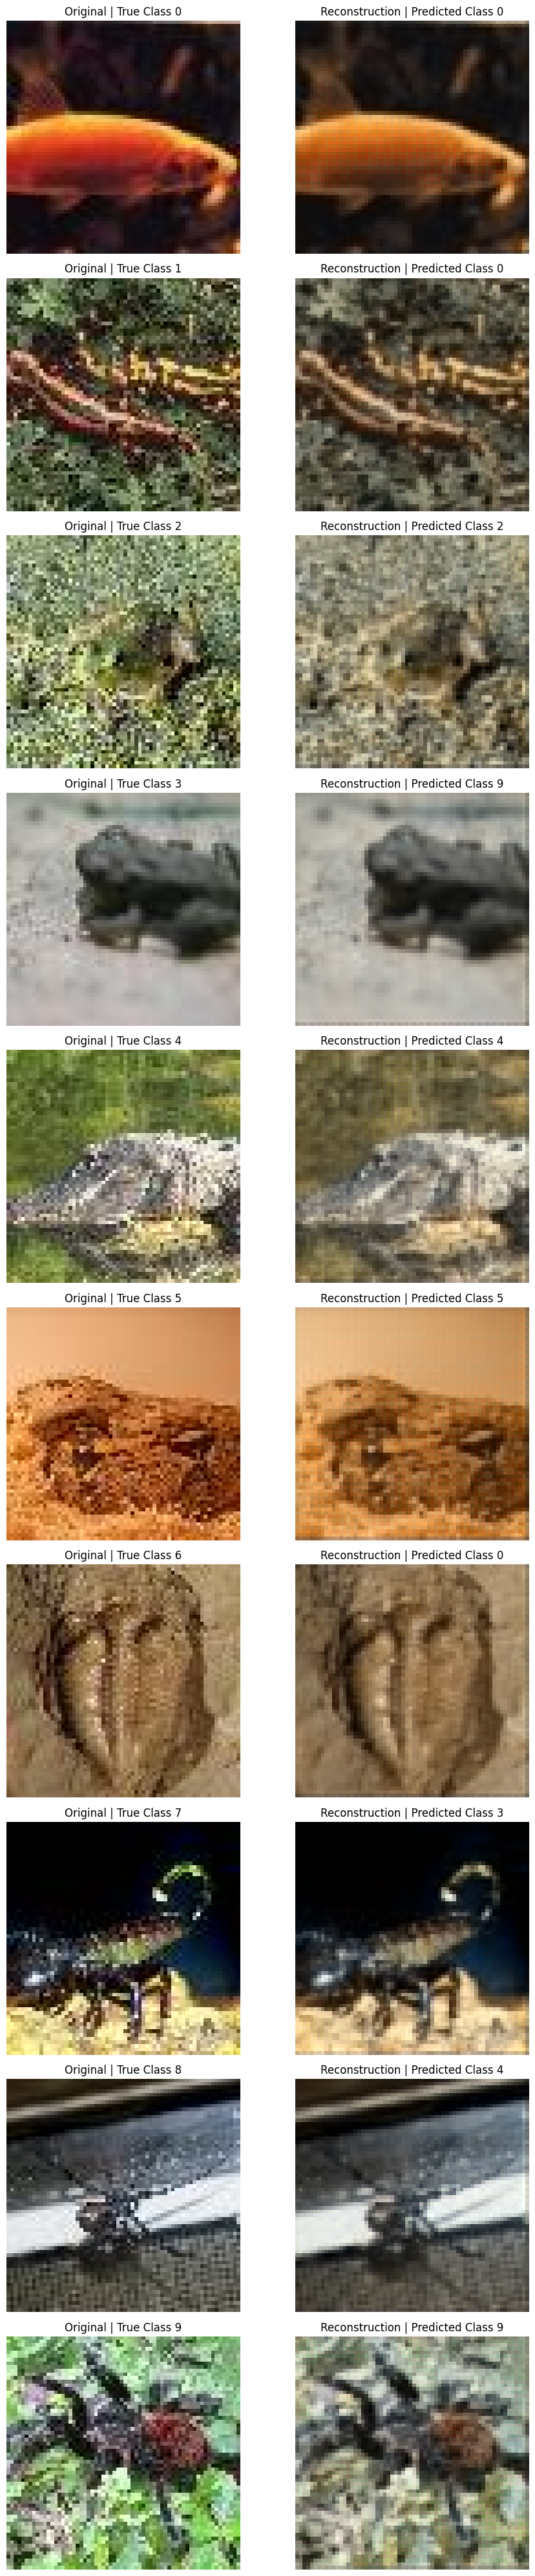

In [26]:
model.eval()

class_examples = {}

for i in range(len(train_subset)):
    image, label = train_subset[i]
    label = int(label)

    if label not in class_examples:
        class_examples[label] = image

    if len(class_examples) == NUM_CLASSES:
        break

fig, axes = plt.subplots(NUM_CLASSES, 2, figsize=(10, NUM_CLASSES * 4))

for row, class_id in enumerate(selected_classes):
    image = class_examples[class_id]

    reconstruction, predicted_r1, predicted_r2, r2, class_state, predicted_class, steps, converged = model.reconstruct(
        image)

    axes[row, 0].imshow(to_display_image(image))
    axes[row, 0].set_title(f"Original | True Class {class_id}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(to_display_image(reconstruction))
    axes[row, 1].set_title(f"Reconstruction | Predicted Class {predicted_class}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

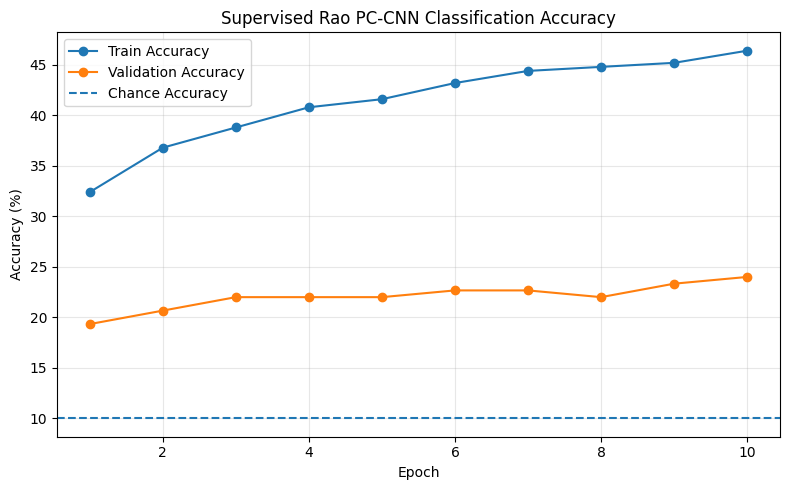

In [27]:
epochs_plot = [item["epoch"] for item in history]
train_accuracy_plot = [item["train_accuracy"] for item in history]
val_accuracy_plot = [item["val_accuracy"] for item in history]

plt.figure(figsize=(8, 5))

plt.plot(epochs_plot, train_accuracy_plot, marker="o", label="Train Accuracy")
plt.plot(epochs_plot, val_accuracy_plot, marker="o", label="Validation Accuracy")

plt.axhline(100.0 / NUM_CLASSES, linestyle="--", label="Chance Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Supervised Rao PC-CNN Classification Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

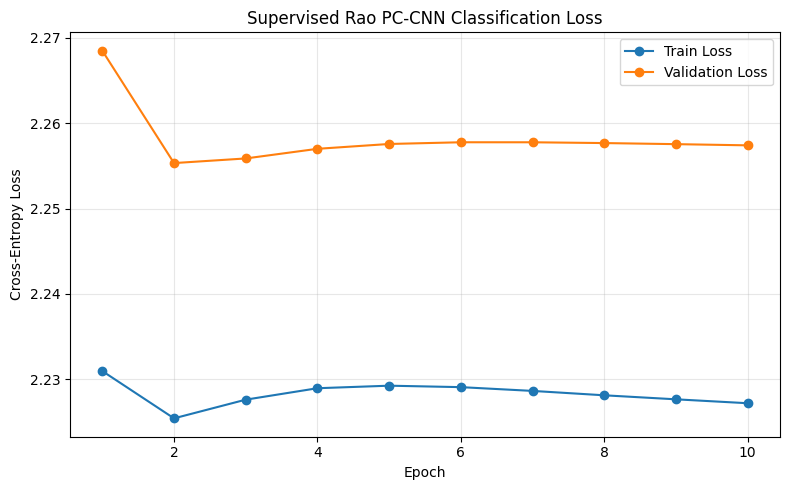

In [28]:
train_loss_plot = [item["train_loss"] for item in history]
val_loss_plot = [item["val_loss"] for item in history]

plt.figure(figsize=(8, 5))

plt.plot(epochs_plot, train_loss_plot, marker="o", label="Train Loss")
plt.plot(epochs_plot, val_loss_plot, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Supervised Rao PC-CNN Classification Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

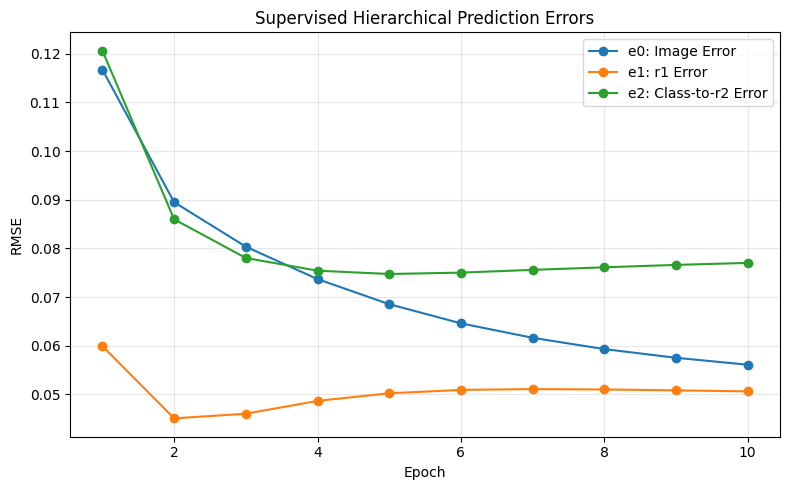

In [29]:
error_0_plot = [item["error_0"] for item in history]
error_1_plot = [item["error_1"] for item in history]
error_2_plot = [item["error_2"] for item in history]

plt.figure(figsize=(8, 5))

plt.plot(epochs_plot, error_0_plot, marker="o", label="e0: Image Error")
plt.plot(epochs_plot, error_1_plot, marker="o", label="e1: r1 Error")
plt.plot(epochs_plot, error_2_plot, marker="o", label="e2: Class-to-r2 Error")

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Supervised Hierarchical Prediction Errors")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

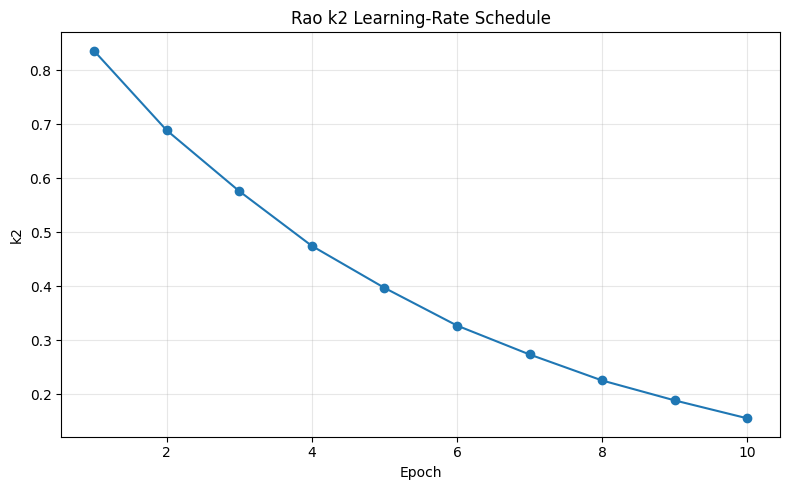

In [30]:
k2_plot = [item["k2"] for item in history]

plt.figure(figsize=(8, 5))

plt.plot(epochs_plot, k2_plot, marker="o")

plt.xlabel("Epoch")
plt.ylabel("k2")
plt.title("Rao k2 Learning-Rate Schedule")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
print("=" * 65)
print("SUPERVISED HIERARCHICAL RAO PC-CNN EXPERIMENT SUMMARY")
print("=" * 65)

print("Device:", device)
print("Input size:", IMAGE_SIZE)
print("Number of classes:", NUM_CLASSES)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Test images:", len(test_subset))

print("Training epochs:", PC_EPOCHS)
print("Inference steps:", INFERENCE_STEPS)
print("Convergence tolerance:", model.convergence_tolerance)

print("Best epoch:", best_epoch)
print("Best validation accuracy:", f"{best_val_accuracy:.2f}%")

print("Final training accuracy:", f"{final_train_accuracy:.2f}%")
print("Final validation accuracy:", f"{final_val_accuracy:.2f}%")

print("Final clean test loss:", f"{test_loss:.4f}")
print("Final clean test accuracy:", f"{test_accuracy:.2f}%")

print("Final clean test convergence:", f"{test_convergence:.2f}%")

print("Training presentations at best epoch:", model.training_input_count)
print("k2 at best epoch:", model.k2)

print("=" * 65)

SUPERVISED HIERARCHICAL RAO PC-CNN EXPERIMENT SUMMARY
Device: mps
Input size: 64
Number of classes: 10
Training images: 500
Validation images: 150
Test images: 100
Training epochs: 10
Inference steps: 100
Convergence tolerance: 1e-05
Best epoch: 10
Best validation accuracy: 24.00%
Final training accuracy: 46.40%
Final validation accuracy: 24.00%
Final clean test loss: 2.2574
Final clean test accuracy: 27.00%
Final clean test convergence: 0.00%
Training presentations at best epoch: 5000
k2 at best epoch: 0.15550512935224337
